In [1]:
import json
from datetime import datetime
import duckdb
import pandas as pd
import random
from IPython.display import Image, display

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# open json plan - stand-in for LLM during testing
plan_lib = json.load(open(PROJECT_ROOT / "planner" / "static_plan.json"))

demo_run_num = random.randint(0, len(plan_lib["demo_runs"]))
plan = plan_lib["demo_runs"][demo_run_num]   # change index to select a demo

print(f'Selected plan ({demo_run_num}) (JSON):\n')
print("{" + ",\n".join("{!r}: {!r}".format(k, v) for k, v in plan.items()) + "}")

run_id = datetime.now().strftime("%Y-%m-%dT%H-%M-%S")
run_dir = PROJECT_ROOT / "runs" / run_id
run_dir.mkdir(parents=True)

json.dump(plan, open(run_dir / "plan.json", "w"), indent=2)

Selected plan (1) (JSON):

{'name': 'CPR11_vibration_rms',
'sql_query': 'sql/entity_sensor_all_history.sql',
'entity_group': 'CPR',
'entity': 'CPR11',
'sensor': 'vibration_rms',
'output_plot_name': 'CPR11_vibration_rms_spc.png'}


In [3]:
# sql extraction
con = duckdb.connect(PROJECT_ROOT / "data" / "mfg.duckdb")
sql = (PROJECT_ROOT / plan["sql_query"]).read_text()

df = con.execute(sql, [plan["entity_group"], plan["entity"], plan["sensor"]]).df()
con.close()

df.to_csv(run_dir / "extracted_data.csv", index=False)

In [4]:
# run preprocess workflow

from preprocess.spc_mode_rolling import preprocess

processed_df = preprocess(
    df,
    processed_dir=PROJECT_ROOT / "data" / "processed"
)

processed_df.to_csv(run_dir / "processed_data.csv", index=False)

processed_df.head(1)

,entity,entity_group,ts,operating_mode,hours_since_maintenance,failure_type,sensor,value,ucl,centerline,lcl,ewma,spc_violation
0,CPR11,CPR,2024-01-01 01:22:00,normal,393.91,none,vibration_rms,2.26,4.874969,2.651293,0.427617,2.26,False


In [5]:
# run plotting workflow

from plots.spc_time_series import plot_spc_time_series

plot_spc_time_series(
    df=processed_df,
    entity_group=plan["entity_group"],
    entity=plan["entity"],
    sensor=plan["sensor"],
    output_path=run_dir / plan["output_plot_name"]
)

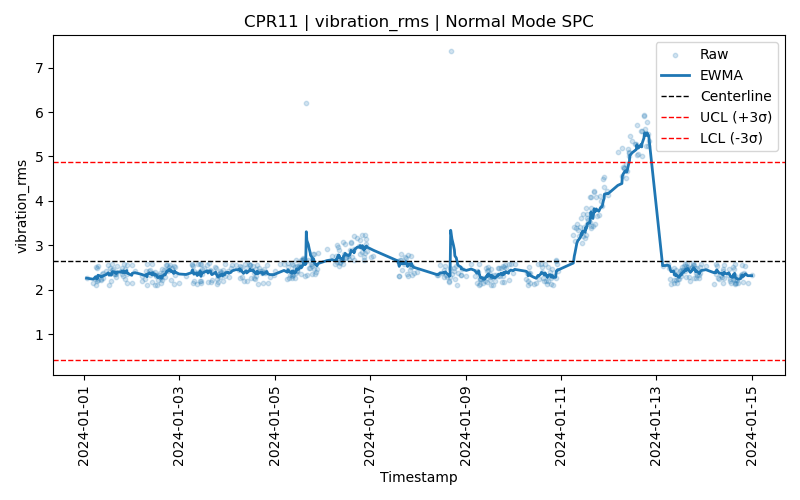

In [6]:
# display saved plot generated in previous step

plot_path = run_dir / plan["output_plot_name"]
display(Image(filename=str(plot_path)))